<a href="https://colab.research.google.com/github/Surhan-Memon/Global-weather-resiprosity/blob/main/global_weather_resiprosity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

               country     location_name  latitude  longitude  \
0          Afghanistan             Kabul     34.52      69.18   
1              Albania            Tirana     41.33      19.82   
2              Algeria           Algiers     36.76       3.05   
3              Andorra  Andorra La Vella     42.50       1.52   
4               Angola            Luanda     -8.84      13.23   
5  Antigua and Barbuda      Saint John's     17.12     -61.85   
6            Argentina      Buenos Aires    -34.59     -58.67   
7              Armenia           Yerevan     40.18      44.51   
8            Australia          Canberra    -35.28     149.22   
9              Austria            Vienna     48.20      16.37   

                         timezone  last_updated_epoch      last_updated  \
0                      Asia/Kabul          1715849100  2024-05-16 13:15   
1                   Europe/Tirane          1715849100  2024-05-16 10:45   
2                  Africa/Algiers          1715849100  2024

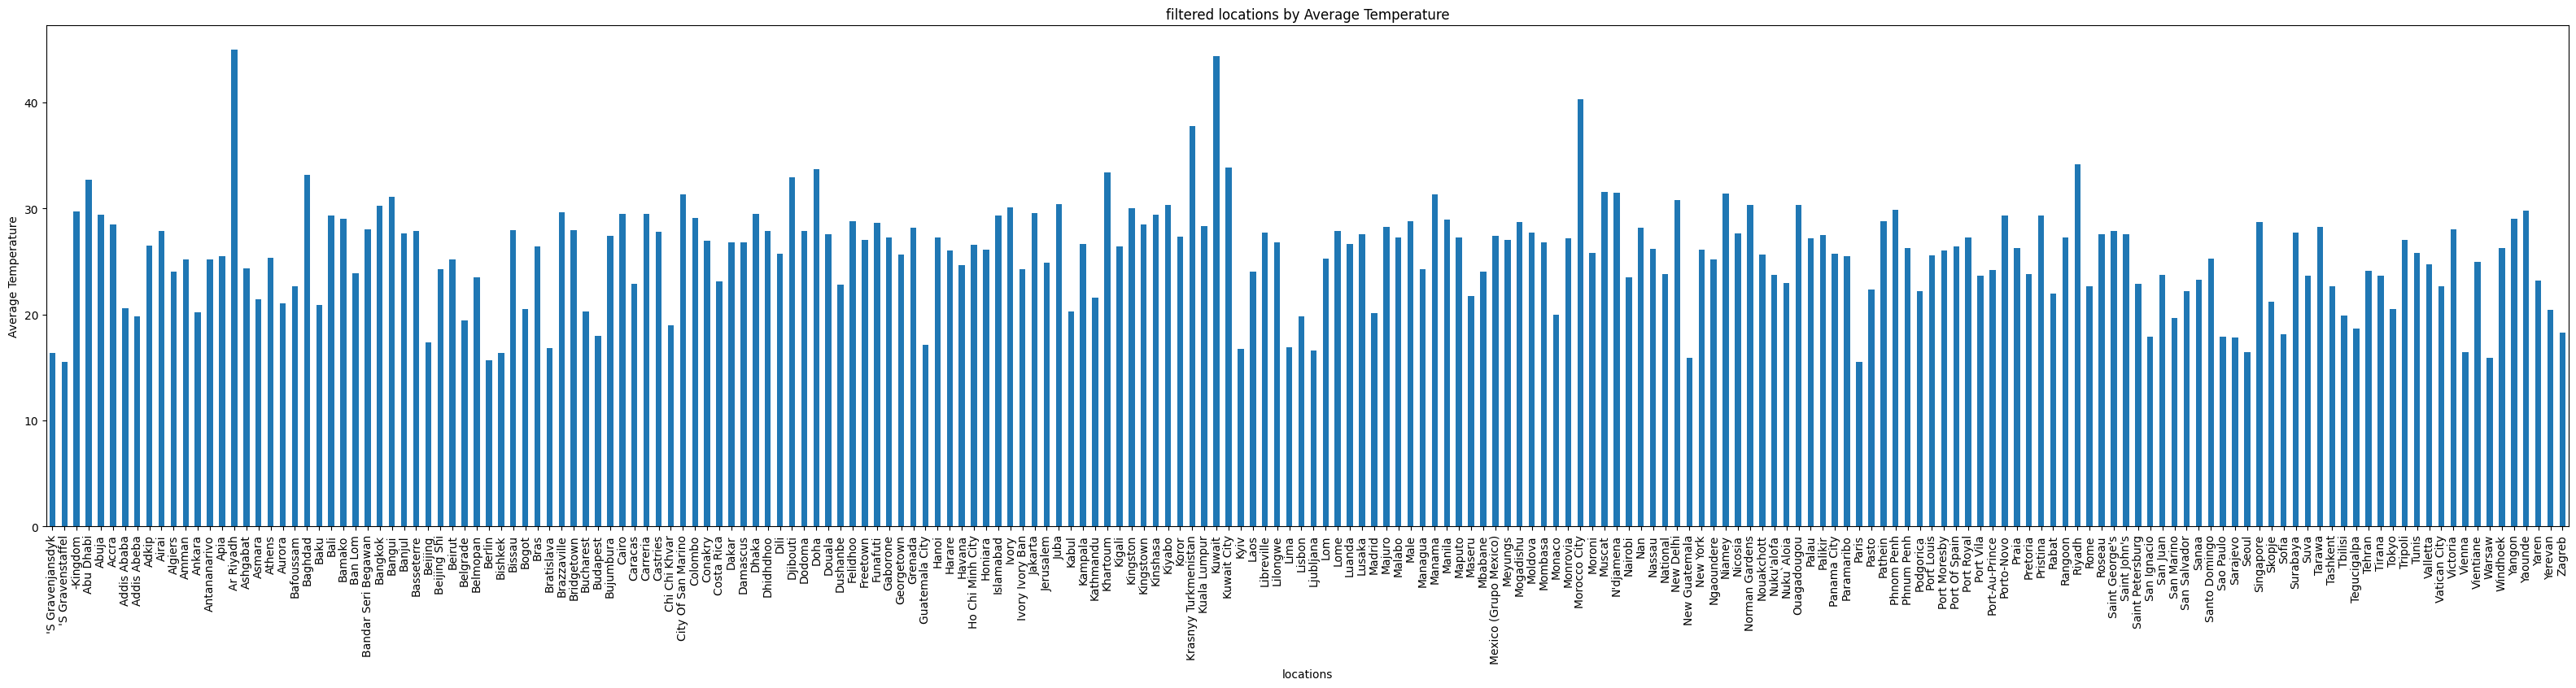

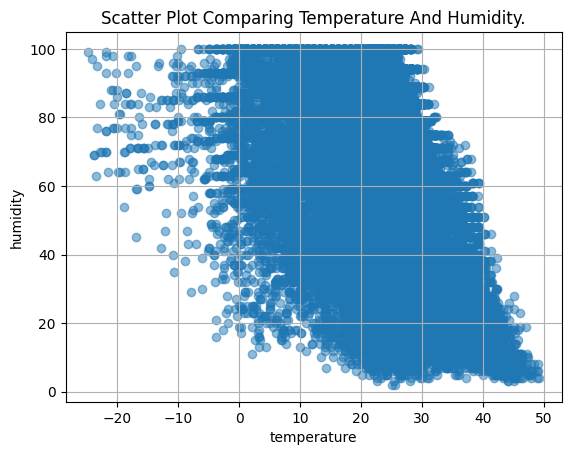

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

weather_x = pd.read_csv('/content/GlobalWeatherRepository.csv')
print(weather_x.head(10))

#Exploring and Cleaning data:

#What are the column names in the dataset?
print(weather_x.columns)

# #How many rows and columns does the dataset have?
print(weather_x.shape)

# #Are there any missing values? If yes, in which columns?
print(weather_x.isnull().sum())

# # What is the data type of each column?
print(weather_x.info())

#Temperature & Weather Conditions:

#What is the average temperature (°C)?
avg_temp = weather_x['temperature_celsius'].mean()
print(avg_temp)

#What was the coldest temperature recorded? On which date?
cold_temp = weather_x['temperature_celsius'].min()
cold_temp_index = weather_x['temperature_celsius'].idxmin()
cold_date = weather_x.loc[cold_temp_index, 'last_updated']
print(cold_date)


#What is the average temperature over the entire dataset?
average_temp_per_location = weather_x.groupby('location_name')['temperature_celsius'].mean()
print(average_temp_per_location)

#What is the highest and lowest humidity recorded?
high_humi = weather_x['humidity'].max()
print(high_humi)

low_humi = weather_x['humidity'].min()
print(low_humi)

#How many rainy days are there in the dataset?
rainy_days = weather_x[weather_x['precip_mm'] > 0].shape[0]
print(rainy_days)

#Data Visualization (Matplotlib):

#Create a bar chart showing the average temperature for each location.
plt.figure(figsize=(40, 8))
filtered_locations = average_temp_per_location[average_temp_per_location > 15]
filtered_locations.plot(kind = 'bar', xlabel = 'locations', ylabel = 'Average Temperature', title = 'filtered locations by Average Temperature')
plt.show()

#Plot a scatter plot comparing temperature and humidity.
plt.scatter(weather_x['temperature_celsius'], weather_x['humidity'], alpha=0.5)
plt.title('Scatter Plot Comparing Temperature And Humidity.')
plt.xlabel('temperature')
plt.ylabel('humidity')
plt.grid()
plt.show()
